# Data Audit
Verify all raw data sources before building features.

Run each section after the corresponding ingest script completes.
All four checks must pass before moving to feature engineering.

In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

RAW = Path('..') / 'data' / 'raw'
UNIVERSE = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'LINKUSDT', 'AVAXUSDT']
DERIBIT_COINS = ['BTC', 'ETH']

def _load(path):
    if not Path(path).exists():
        return None
    return pd.read_parquet(path)

print('RAW data root:', RAW.resolve())

RAW data root: C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research\topics\ml-prediction\data\raw


## Check 1 — Date range
Every source must cover at least 2020-01-01 to today.
Funding starts 2019-09 for BTC; OI/LS start ~2020-01.

In [7]:
print(f'{'SOURCE':<35} {'FIRST':<12} {'LAST':<12} {'ROWS':>6}')
print('-' * 70)

# Futures: funding, OI, L/S
for source, folder, suffix in [
    ('funding',   'funding',   '_funding.parquet'),
    ('open_interest', 'oi',    '_oi.parquet'),
    ('longshort', 'longshort', '_ls.parquet'),
]:
    for sym in UNIVERSE:
        df = _load(RAW / folder / f'{sym}{suffix}')
        if df is None:
            print(f'  {sym} {source:<20} MISSING')
        else:
            print(f'  {sym} {source:<20} {str(df.index[0].date()):<12} {str(df.index[-1].date()):<12} {len(df):>6}')

# Deribit DVOL
for coin in DERIBIT_COINS:
    df = _load(RAW / 'deribit' / f'{coin}_dvol.parquet')
    label = f'{coin} dvol'
    if df is None:
        print(f'  {label:<35} MISSING')
    else:
        print(f'  {label:<35} {str(df.index[0].date()):<12} {str(df.index[-1].date()):<12} {len(df):>6}')

# Macro
df = _load(RAW / 'macro' / 'macro_daily.parquet')
if df is None:
    print('  macro                               MISSING')
else:
    for col in df.columns:
        s = df[col].dropna()
        print(f'  macro {col:<29} {str(s.index[0].date()):<12} {str(s.index[-1].date()):<12} {len(s):>6}')

# On-chain
df = _load(RAW / 'onchain' / 'onchain_daily.parquet')
if df is None:
    print('  onchain                             MISSING')
else:
    for col in df.columns:
        s = df[col].dropna()
        print(f'  onchain {col:<28} {str(s.index[0].date()):<12} {str(s.index[-1].date()):<12} {len(s):>6}')

SOURCE                              FIRST        LAST           ROWS
----------------------------------------------------------------------
  BTCUSDT funding              2019-09-10   2026-04-30     2425
  ETHUSDT funding              2019-11-27   2026-04-30     2347
  SOLUSDT funding              2020-09-13   2026-04-30     2056
  BNBUSDT funding              2020-02-10   2026-04-30     2272
  XRPUSDT funding              2020-01-06   2026-04-30     2307
  DOGEUSDT funding              2020-07-10   2026-04-30     2121
  LINKUSDT funding              2020-01-17   2026-04-30     2296
  AVAXUSDT funding              2020-09-22   2026-04-30     2047
  BTCUSDT open_interest        2020-09-01   2026-04-30     2068
  ETHUSDT open_interest        2021-12-01   2026-04-30     1612
  SOLUSDT open_interest        2021-12-01   2026-04-30     1612
  BNBUSDT open_interest        2021-12-01   2026-04-30     1612
  XRPUSDT open_interest        2021-12-01   2026-04-30     1612
  DOGEUSDT open_interest 

## Check 2 — Coverage gaps
Flag any symbol with >2% missing dates (trading days with no row).
Crypto trades every day — gaps mean API failures or pagination bugs.

In [8]:
def gap_report(df, label):
    if df is None or df.empty:
        print(f'  {label:<40} MISSING')
        return
    full_range = pd.date_range(df.index[0], df.index[-1], freq='D')
    missing = full_range.difference(df.index)
    pct = len(missing) / len(full_range) * 100
    flag = '  <<< GAP WARNING' if pct > 2 else ''
    print(f'  {label:<40} {len(missing):>4} missing days  ({pct:.1f}%){flag}')

print('Gap analysis (>2% = investigate)\n')
for sym in UNIVERSE:
    gap_report(_load(RAW / 'funding'   / f'{sym}_funding.parquet'), f'{sym} funding')
    gap_report(_load(RAW / 'oi'        / f'{sym}_oi.parquet'),      f'{sym} oi')
    gap_report(_load(RAW / 'longshort' / f'{sym}_ls.parquet'),      f'{sym} ls_ratio')

for coin in DERIBIT_COINS:
    gap_report(_load(RAW / 'deribit' / f'{coin}_dvol.parquet'), f'{coin} dvol')

macro = _load(RAW / 'macro' / 'macro_daily.parquet')
if macro is not None:
    # Macro only on trading days — use business days not calendar days
    for col in macro.columns:
        s = macro[col].dropna()
        bday_range = pd.bdate_range(s.index[0], s.index[-1])
        missing = len(bday_range) - len(s)
        pct = missing / len(bday_range) * 100
        flag = '  <<< GAP WARNING' if pct > 3 else ''
        print(f'  macro {col:<35} {missing:>4} missing bdays ({pct:.1f}%){flag}')

Gap analysis (>2% = investigate)

  BTCUSDT funding                             0 missing days  (0.0%)
  BTCUSDT oi                                  0 missing days  (0.0%)
  BTCUSDT ls_ratio                            0 missing days  (0.0%)
  ETHUSDT funding                             0 missing days  (0.0%)
  ETHUSDT oi                                  0 missing days  (0.0%)
  ETHUSDT ls_ratio                            0 missing days  (0.0%)
  SOLUSDT funding                             0 missing days  (0.0%)
  SOLUSDT oi                                  0 missing days  (0.0%)
  SOLUSDT ls_ratio                            0 missing days  (0.0%)
  BNBUSDT funding                             0 missing days  (0.0%)
  BNBUSDT oi                                  0 missing days  (0.0%)
  BNBUSDT ls_ratio                            0 missing days  (0.0%)
  XRPUSDT funding                             0 missing days  (0.0%)
  XRPUSDT oi                                  0 missing days  (0.0%)


## Check 3 — Cross-source alignment
Join all sources on date for BTC (representative coin).
Null heatmap shows exactly when each source starts and if there are gaps.

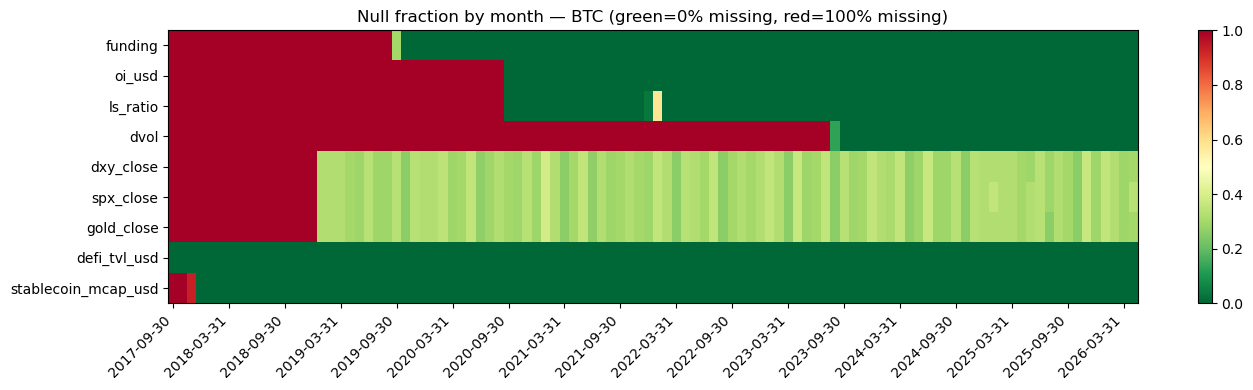


Joined shape: (3138, 9)
Total null %: {'funding': 0.227, 'oi_usd': 0.341, 'ls_ratio': 0.347, 'dvol': 0.681, 'dxy_close': 0.412, 'spx_close': 0.413, 'gold_close': 0.412, 'defi_tvl_usd': 0.0, 'stablecoin_mcap_usd': 0.02}


In [9]:
sym = 'BTCUSDT'

frames = {}

df = _load(RAW / 'funding'   / f'{sym}_funding.parquet')
if df is not None: frames['funding'] = df['funding_sum_1d']

df = _load(RAW / 'oi'        / f'{sym}_oi.parquet')
if df is not None: frames['oi_usd'] = df['oi_usd']

df = _load(RAW / 'longshort' / f'{sym}_ls.parquet')
if df is not None: frames['ls_ratio'] = df['ls_ratio']

df = _load(RAW / 'deribit' / 'BTC_dvol.parquet')
if df is not None: frames['dvol'] = df['dvol']

macro = _load(RAW / 'macro' / 'macro_daily.parquet')
if macro is not None:
    for col in macro.columns:
        frames[col] = macro[col]

onchain = _load(RAW / 'onchain' / 'onchain_daily.parquet')
if onchain is not None:
    for col in onchain.columns:
        frames[col] = onchain[col]

joined = pd.DataFrame(frames)

# Null heatmap — monthly resolution
monthly_nulls = joined.resample('ME').apply(lambda x: x.isna().mean())

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(monthly_nulls.T.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(monthly_nulls.columns)))
ax.set_yticklabels(monthly_nulls.columns)
ax.set_xticks(range(0, len(monthly_nulls), 6))
ax.set_xticklabels([str(d.date()) for d in monthly_nulls.index[::6]], rotation=45, ha='right')
ax.set_title('Null fraction by month — BTC (green=0% missing, red=100% missing)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f'\nJoined shape: {joined.shape}')
print(f'Total null %: {joined.isna().mean().round(3).to_dict()}')

## Check 4 — Walk-forward feasibility
Confirm each symbol has enough history for a 3-year rolling train window.
Minimum needed: 1095 rows (3 years) + 90 rows (3-month val) = 1185 rows.

In [10]:
MIN_ROWS = 1185

print(f'Walk-forward feasibility (need >= {MIN_ROWS} rows per source)\n')
print(f'  {"SOURCE":<40} {"ROWS":>6}  STATUS')
print('-' * 60)

all_ok = True
for sym in UNIVERSE:
    df = _load(RAW / 'funding' / f'{sym}_funding.parquet')
    rows = len(df) if df is not None else 0
    status = 'OK' if rows >= MIN_ROWS else f'INSUFFICIENT (need {MIN_ROWS - rows} more)'
    if rows < MIN_ROWS: all_ok = False
    print(f'  {sym + " funding":<40} {rows:>6}  {status}')

for coin in DERIBIT_COINS:
    df = _load(RAW / 'deribit' / f'{coin}_dvol.parquet')
    rows = len(df) if df is not None else 0
    # DVOL only from 2021 — shorter window is expected
    min_dvol = 365
    status = 'OK (limited history — expected)' if rows >= min_dvol else f'INSUFFICIENT'
    print(f'  {coin + " dvol":<40} {rows:>6}  {status}')

print()
if all_ok:
    print('All sources have sufficient history for walk-forward. Ready for feature engineering.')
else:
    print('Some sources are too short. Check ingest scripts for pagination issues.')

Walk-forward feasibility (need >= 1185 rows per source)

  SOURCE                                     ROWS  STATUS
------------------------------------------------------------
  BTCUSDT funding                            2425  OK
  ETHUSDT funding                            2347  OK
  SOLUSDT funding                            2056  OK
  BNBUSDT funding                            2272  OK
  XRPUSDT funding                            2307  OK
  DOGEUSDT funding                           2121  OK
  LINKUSDT funding                           2296  OK
  AVAXUSDT funding                           2047  OK
  BTC dvol                                   1000  OK (limited history — expected)
  ETH dvol                                   1000  OK (limited history — expected)

All sources have sufficient history for walk-forward. Ready for feature engineering.


## Summary
Paste results here before moving to `2_features.ipynb`.

| Check | Status | Notes |
|---|---|---|
| Date range | | |
| Coverage gaps | | |
| Cross-source alignment | | |
| WF feasibility | | |